Dieser Code trainiert und evaluiert das stacked LSTM-Modell anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}


In [ ]:
 import pandas as pd
 import matplotlib.pyplot  as plt
 import seaborn as sns
 import numpy as np
 import sklearn
 import sklearn.metrics as metrics
 from sklearn.model_selection import train_test_split
 from tensorflow.keras.preprocessing.text import Tokenizer
 from tensorflow.keras.preprocessing.sequence import pad_sequences
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

In [ ]:
#nur nötig um auf google drive auf dateien zugreifen zu können

#from google.colab import drive
#drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#datensatz laden
df = pd.read_csv(
    #"/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
    "de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [ ]:

df["labels"].isna().sum()
df[df["labels"].isna()]


,text,labels,source,dataset,nb_annotators
2519,Das macht Angst....,NaN,None,None,NaN


In [ ]:
#zeile mit nan werte löschen
df=df.dropna(subset=["labels"])

In [ ]:
df["labels"].isna().sum()

np.int64(0)

In [ ]:
#dataframe bilden mit text und label 
X=df["text"]
y=df["labels"].astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
#dataframe bilden für train und test mit nur text und label
X=df["text"]
y=df["labels"].astype(int)

Train-, Test- und Validierungsdatensatz werden eingeteilt 

In [ ]:

#TRAIN /TEST
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.1, random_state=42)

der tokenizer wird geladen und auf dem traindatensatz geladen, er erstellt das "Wörterbuch" für das Modell und setzt das Wort in einen eindeutigen  numerischen Index

In [ ]:
tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

der tokenizer wird nun auf die anderen datensätze geladen damit nun auch dort die wörter einen numerischen index habe

In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

#datensätze werden gepadded, damit sie die gleiche länge haben, da LSTM nur mit gleich langen Sequenzen arbeiten kann
maxlen=175
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxlen, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

das earlystopping wird definiert. Dieses guckt über die Metrik val_loss ob sich das modell verbessert oder nicht. 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    patience=2, #wenn es merkt, dass das Modell sich nicht verbessert dann werden zwei Epochen abgewartet und dann wird das Training abgebrochen
    restore_best_weights=True #der beste Zustand des Modells wird gespeichert, damit das Modell nicht übertrainiert wird und die besten Gewichte beibehalten werden
)


In [ ]:
modelStacked=Sequential() #sequentielles modell
modelStacked.add(Embedding(input_dim=50000, output_dim=64, input_length=maxlen))#embedding layer
modelStacked.add(LSTM(128,return_sequences=True,dropout=0.3))#erstes lstm layer mit 128 lstm einheiten und 30% dropout 
modelStacked.add(LSTM(64,dropout=0.3,recurrent_dropout=0.3))#zweites lstm layer mit 64 lstm einheiten und 30% dropout und 30% recurrent dropout
modelStacked.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
modelStacked.compile( #modell kompilieren
    loss="binary_crossentropy", #verlustfunktion 
    optimizer="adam", #modell gewichtung
    metrics=["accuracy"]
    )
historyStacked=modelStacked.fit( #modell trainiert
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val), #pro epoche wird die validierung durchgeführt
    epochs=10, #maximal 10 epochen
    batch_size=64, #menge die gleichzeitig klassifiziert wird
    #class_weight={0:1,1:7},
    callbacks=[es] #earlystopping wird aktiviert
)

Epoch 1/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 394s 671ms/step - accuracy: 0.8734 - loss: 0.3817 - val_accuracy: 0.8773 - val_loss: 0.3743
Epoch 2/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 380s 667ms/step - accuracy: 0.8746 - loss: 0.3785 - val_accuracy: 0.8773 - val_loss: 0.3723
Epoch 3/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 379s 667ms/step - accuracy: 0.8746 - loss: 0.3780 - val_accuracy: 0.8773 - val_loss: 0.3778
Epoch 4/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 376s 660ms/step - accuracy: 0.8746 - loss: 0.3781 - val_accuracy: 0.8773 - val_loss: 0.3722
Epoch 5/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 383s 663ms/step - accuracy: 0.8746 - loss: 0.3781 - val_accuracy: 0.8773 - val_loss: 0.3722
Epoch 6/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 379s 666ms/step - accuracy: 0.8747 - loss: 0.3780 - val_accuracy: 0.8771 - val_loss: 0.3731


In [ ]:
#Modell speichern
import joblib
joblib.dump(modelStacked,"/content/drive/MyDrive/Colab Notebooks/LSTM_Stacked_model_normalRICHITG.plk")

['/content/drive/MyDrive/Colab Notebooks/LSTM_Stacked_model_normalRICHITG.plk']

fertiges Modell wird validiert
das Mdoell wird auf dem validierungsdatensatz laufen gelassen und die mit predict() errechnetet Wahrscheinlichkeiten werden mit der standardschwelle 0,5 verglichen.
die gerechneten wahrscheinlichkeiten werdne in der datei gespeichert mit dem text und dem label, anschließend wird dei optimale schwelle berechnet und anhand des f1-scores bewertet

In [ ]:
y_val_proba=modelStacked.predict(X_val_padded).flatten()
y_valpred=(y_val_proba>0.5).astype(int)

#wahrscheinlichkeit speichern
with open("lstm_validierung_stacked_normalRICHITG.txt","w") as fd:
  for text, label, proba in zip(X_val, y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {label}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)


#Klassifikationsschwellen
schwellen=np.arange(0.0,1.01,0.01)#die schwelle geht von 0 bis 1 in 0.01 schritten
beste_schwelle=0
bester_f1=0
for t in schwellen:
  y_val_pred_schwelle=(y_val_proba>t).astype(int)#wenn die wahrscheinlichkeit größer als die schwelle ist, dann wird es als 1 klassifiziert
  f1=metrics.f1_score(y_val,y_val_pred_schwelle) #f1 wird berechnet
  if f1>bester_f1:#wenn neuer f1 score größer ist als der bisher beste f1 score, dann wird
    bester_f1=f1#neuer f1 zu bester_f1
    beste_schwelle=t#t (neue schwelle) zu bester_schwelle
    print(f"Beste Schwelle: {beste_schwelle}\n")
    print(f"Beste F1-Score: {bester_f1}\n")

print(f"Beste Schwellenwert: {beste_schwelle}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step
Beste Schwelle: 0.0

Beste F1-Score: 0.2185022026431718

Beste Schwellenwert: 0.0


der Validierungsloss und Trainingsloss wird im verlauf der epochen angezeigt, dies geschieht mithilfe von matplotlib als liniendiagramm. In historyStacked wird der Zustand des Modells nach einer Epoche gespeichert

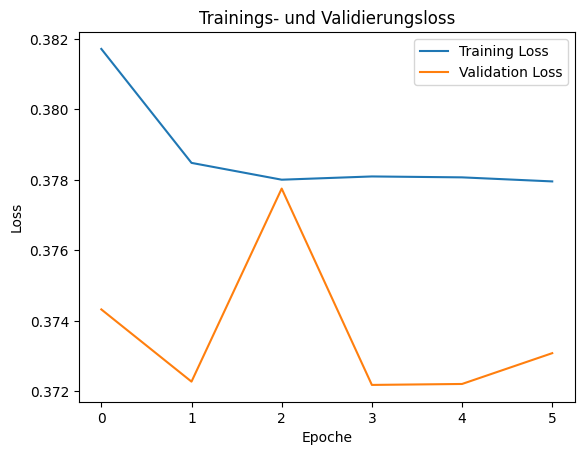

In [ ]:
plt.plot(historyStacked.history['loss'], label='Training Loss')
plt.plot(historyStacked.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.title("Trainings- und Validierungsloss")
plt.show()

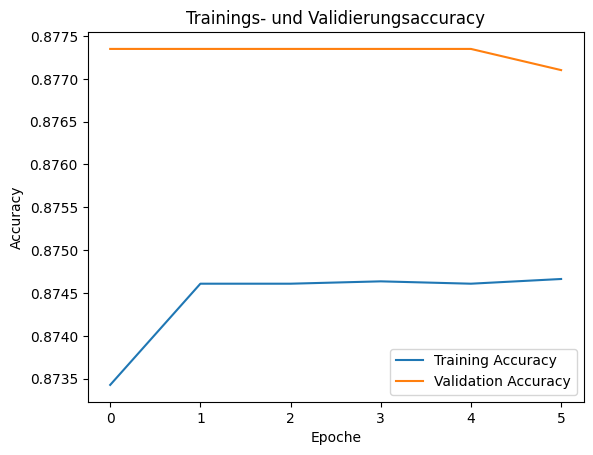

In [ ]:
#die Accuracy wird geplottet, um zu sehen, wie gut das Modell trainiert wurde und wie gut es auf den Validierungsdaten abschneidet.
plt.plot(historyStacked.history['accuracy'], label='Training Accuracy')
plt.plot(historyStacked.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Trainings- und Validierungsaccuracy")
plt.show()

Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

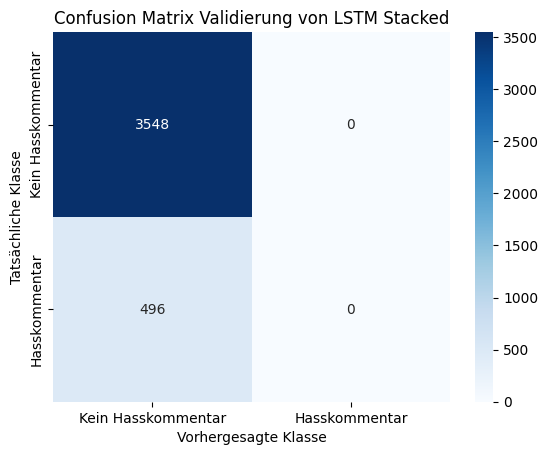

In [ ]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
annot=True, #zeigt werte an
    fmt="d", # gibt ganze zahl an
    cmap="Blues",# farbschema, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Validierung von LSTM Stacked")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8773491592482691
Precision:  0.0
Recall:  0.0
Specificity:  1.0
F1-Score:  0.0
Macro Recall:  0.5
Macro F1-Score:  0.4673340358271865


dsa modell wird mit der standardschwelle von 0,5 auf dem testdatensatz laufegelassen dies gescheit mit modell.predict()

In [ ]:
y_pred=(modelStacked.predict(X_test_padded)>0.5).astype(int)
#print(classification_report(y_test,y_pred)

316/316 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step


Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

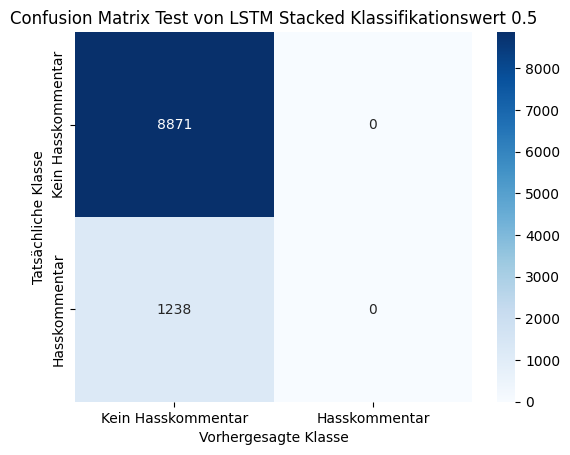

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
annot=True, #zeigt werte an
    fmt="d", # gibt ganze zahl an
    cmap="Blues",# farbschema, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Test von LSTM Stacked Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
#metriken berechnen
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.877534869917895
Precision:  0.0
Recall:  0.0
Specificity:  1.0
F1-Score:  0.0
Macro Recall:  0.5
Macro F1-Score:  0.46738672286617494


das mdoell wird mit der besten schwelle auf dem testdatensatz laufengelassen

In [ ]:
y_pred=(modelStacked.predict(X_test_padded)>beste_schwelle).astype(int)
#print(classification_report(y_test,y_pred)

316/316 ━━━━━━━━━━━━━━━━━━━━ 43s 135ms/step


Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

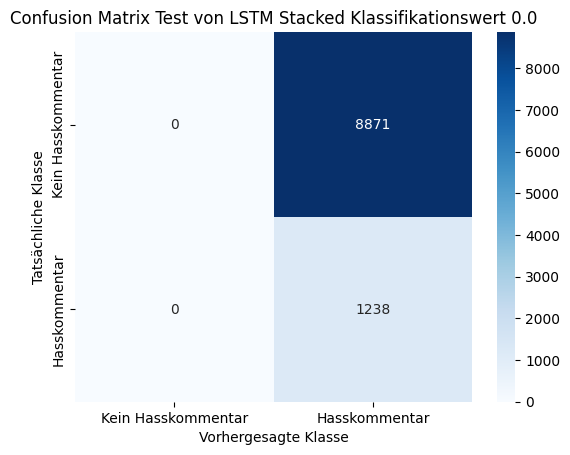

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
annot=True, #zeigt werte an
    fmt="d", # gibt ganze zahl an
    cmap="Blues",# farbschema, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title(f"Confusion Matrix Test von LSTM Stacked Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
#metriken berechnen
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.12246513008210505
Precision:  0.12246513008210505
Recall:  1.0
Specificity:  0.0
F1-Score:  0.218207455715167
Macro Recall:  0.5
Macro F1-Score:  0.1091037278575835
